### Building a character-level MLP (Makemore-style)

This notebook walks through building a **character-level neural language model** that learns to generate baby names, inspired by the "makemore" series.

At a high level, we will:
- **Load and inspect the dataset** of names.
- **Build a character vocabulary** and map characters to integers.
- Turn each name into supervised training examples $(X, Y)$ using a **fixed-length context window**.
- Learn **character embeddings** and feed them into a simple **2-layer MLP**.
- Train the network using **cross-entropy loss** and **stochastic gradient descent**, including a **learning-rate sweep**.

The markdown cells along the way try to explain the *intuition* behind each code block, not just what the code does mechanically.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Dataset: a list of baby names

We start from a **plain text file** `names.txt`, where each line is a single baby name.

The modeling goal is:
- Given a **sequence of previous characters** in a name, predict the **next character**.
- If we can repeatedly sample next characters from the model, we can **generate new, realistic-looking names**.

The first few cells simply **load the raw names** into memory so we can inspect what the data looks like before turning it into supervised training examples.

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
print("Length of words: ", len(words))

Length of words:  32033


### Character vocabulary and special tokens

Before we can feed names to a neural network, we need to **turn characters into integers**:

- `chars` collects all **unique characters** that appear in the dataset.
- `stoi` (**string-to-index**) maps each character to an integer ID.
- `itos` (**index-to-string**) reverses that mapping.
- We reserve index `0` for a special `'.'` character that means **"start/end of a word"**.

Intuition:
- The model never sees raw text; it only sees **integer IDs**.
- Later we will use these IDs to **look up embeddings**, so each character can be represented by a small learned vector instead of a sparse one-hot encoding.

In [4]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = { s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print("Integer to string mapping: ", itos)

Integer to string mapping:  {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


### Turning names into (input, target) pairs

Here we transform each name into many small **training examples** using a fixed **context window** of length `block_size = 3`:

- `context` keeps the last 3 character IDs we've seen so far (initialized to all zeros = `"..."`, i.e. three start tokens).
- For each new character `ch` in the name plus a final `'.'` (end token):
  - We record the current `context` as one row of `X`.
  - We record the **next character ID** `ix` as the corresponding element of `Y`.
  - Then we **slide the window** by dropping the oldest character and appending `ix`.

So each row of `X` says *"given these last 3 characters"* and the corresponding element in `Y` says *"this was the next character"*. This is the core **supervised learning signal** the network will try to model.

In [5]:
# Build the dataset
# Context length: How many characters to look back when predicting the next character?
block_size = 3
X, Y = [], []

for w in words[:5]:
    print("Word: ", w)
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)

        print(''.join(itos[i] for i in context), '->', itos[ix])

        # update context
        context = context[1:] + [ix]
        
    print("-"*40)

X = torch.tensor(X)
Y = torch.tensor(Y)        

Word:  emma
... -> e
..e -> m
.em -> m
emm -> a
mma -> .
----------------------------------------
Word:  olivia
... -> o
..o -> l
.ol -> i
oli -> v
liv -> i
ivi -> a
via -> .
----------------------------------------
Word:  ava
... -> a
..a -> v
.av -> a
ava -> .
----------------------------------------
Word:  isabella
... -> i
..i -> s
.is -> a
isa -> b
sab -> e
abe -> l
bel -> l
ell -> a
lla -> .
----------------------------------------
Word:  sophia
... -> s
..s -> o
.so -> p
sop -> h
oph -> i
phi -> a
hia -> .
----------------------------------------


In [6]:
print(X.shape, X.dtype)
print(Y.shape, Y.dtype)

torch.Size([32, 3]) torch.int64
torch.Size([32]) torch.int64


### From one-hot vectors to learned embeddings

`C` is our **character embedding matrix** of shape `(27, 2)`:

- Each row corresponds to one character ID (0–26).
- Each row is a small **learned 2D vector** representing that character.

The next few cells illustrate two equivalent ways to get an embedding for character ID `5`:
- Using **direct indexing**: `C[5]`.
- Using a **one-hot vector** `F.one_hot(..., num_classes=27)` and a matrix multiply with `C`.

Intuition:
- One-hot vectors are high-dimensional and sparse; embeddings are **low-dimensional and dense**.
- Learning `C` lets the model discover **similarity structure** between characters (e.g., vowels vs consonants) instead of treating them as unrelated symbols.

In [7]:
C = torch.randn((27, 2)) # Each of the 27 characters will have 2 dimensional embedding
print(C)

tensor([[ 0.3075,  0.2033],
        [ 0.3667, -0.4151],
        [ 2.4937, -0.8100],
        [ 1.4704,  0.0190],
        [-0.1001,  1.1370],
        [ 1.4221, -0.4037],
        [-0.6122, -0.2385],
        [ 0.6060, -0.2035],
        [-0.3379, -0.3723],
        [ 1.0680,  0.3788],
        [-1.5941,  0.1073],
        [ 0.2481,  0.3836],
        [-2.5703,  0.7115],
        [ 0.9602, -0.4164],
        [-0.4774, -0.7738],
        [ 0.8219,  0.6491],
        [ 0.1768,  1.7483],
        [ 1.5980, -0.8554],
        [ 1.3811,  2.1048],
        [-0.7001,  1.7920],
        [-1.1337,  1.7620],
        [-1.7734, -0.2997],
        [ 0.2864, -2.2895],
        [-1.0437, -1.0110],
        [ 0.2094, -2.4628],
        [ 0.3028,  0.5023],
        [ 0.4836,  0.4533]])


In [8]:
C[5]

tensor([ 1.4221, -0.4037])

In [9]:
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([ 1.4221, -0.4037])

In [10]:
# indexing with lists in python
C[torch.tensor([5, 6, 7, 7, 7])]

tensor([[ 1.4221, -0.4037],
        [-0.6122, -0.2385],
        [ 0.6060, -0.2035],
        [ 0.6060, -0.2035],
        [ 0.6060, -0.2035]])

In [11]:
# Similarly we can index using higher dimensional tensors
C[X].shape

torch.Size([32, 3, 2])

In [12]:
print(X[13, 2])
print(C[X][13, 2])

tensor(1)
tensor([ 0.3667, -0.4151])


In [13]:
print(C[1])

tensor([ 0.3667, -0.4151])


### MLP architecture: embeddings → hidden layer → logits

Now that each `(context of 3 chars)` is represented as `emb` with shape `(batch_size, 3, 2)`, we:

- **Flatten** the 3 embeddings per example into a single 6D vector: `emb.view(-1, 6)`.
- Feed this into a hidden layer with weights `W1` of shape `(6, 100)` and bias `b1` (size 100).
- Apply a nonlinearity `tanh` to get hidden activations `h`.
- Map `h` to output `logits` with `W2` of shape `(100, 27)` and bias `b2` (size 27).

Intuition:
- The hidden layer lets the model learn **nonlinear combinations** of the 3-character context.
- The final 27-dimensional logits correspond to **unnormalized scores** for each possible next character; after exponentiating and normalizing we get a **probability distribution** over the alphabet.

In [14]:
emb = C[X]
print(emb.shape)

torch.Size([32, 3, 2])


In [15]:
# Defining the input layer of neural network
W1 = torch.randn((6, 100)) # 3 words * 2 features -> 6. And take 100 neurons
b1 = torch.randn(100)

In [16]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

### Reshaping embeddings into a flat input vector

`emb` currently has shape `torch.Size([32, 3, 2])`:

- 32 examples in the batch.
- Context length of 3 characters.
- Each character mapped to a 2-dimensional embedding.

To feed this into a single linear layer `W1` expecting a **flat feature vector** per example, we conceptually want to **concatenate** the 3 embeddings along the feature dimension:

- For each example: `[emb[0], emb[1], emb[2]] ->` a single 6D vector.
- In code, `torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)` stacks the three `(32, 2)` slices into a `(32, 6)` matrix.

This `(batch_size, context_size * embedding_dim)` layout is the standard way to turn a fixed-length context of embeddings into a flat input suitable for an MLP layer like `W1`. 

In [17]:
# What we want the input to be like?
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim = 1).shape

torch.Size([32, 6])

In [18]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [19]:
a = torch.arange(18)
print("Original: ", a)
print("Original shape: ", a.shape)
print("Viewing as 3x6: ", a.view(3, 6))
print("Viewing as 6x3: ", a.view(6, 3))
print("Viewing as 2x9: ", a.view(2, 9))
print("Viewing as 2x3x3: ", a.view(2, 3, 3))



Original:  tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])
Original shape:  torch.Size([18])
Viewing as 3x6:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17]])
Viewing as 6x3:  tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11],
        [12, 13, 14],
        [15, 16, 17]])
Viewing as 2x9:  tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])
Viewing as 2x3x3:  tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[ 9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]]])


View function doesn't move memory here and there. Tensor values are stored as a 1D vector list, and `view()` only changes how the values are arranged. <br />
PyTorch internals blog: https://blog.ezyang.com/2019/05/pytorch-internals/

In [20]:
a.storage()

/var/folders/7x/6jy7bspj7h1bjyhcrx746g6h0000gn/T/ipykernel_25951/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [21]:
emb.view(32, 6)

tensor([[ 0.3075,  0.2033,  0.3075,  0.2033,  0.3075,  0.2033],
        [ 0.3075,  0.2033,  0.3075,  0.2033,  1.4221, -0.4037],
        [ 0.3075,  0.2033,  1.4221, -0.4037,  0.9602, -0.4164],
        [ 1.4221, -0.4037,  0.9602, -0.4164,  0.9602, -0.4164],
        [ 0.9602, -0.4164,  0.9602, -0.4164,  0.3667, -0.4151],
        [ 0.3075,  0.2033,  0.3075,  0.2033,  0.3075,  0.2033],
        [ 0.3075,  0.2033,  0.3075,  0.2033,  0.8219,  0.6491],
        [ 0.3075,  0.2033,  0.8219,  0.6491, -2.5703,  0.7115],
        [ 0.8219,  0.6491, -2.5703,  0.7115,  1.0680,  0.3788],
        [-2.5703,  0.7115,  1.0680,  0.3788,  0.2864, -2.2895],
        [ 1.0680,  0.3788,  0.2864, -2.2895,  1.0680,  0.3788],
        [ 0.2864, -2.2895,  1.0680,  0.3788,  0.3667, -0.4151],
        [ 0.3075,  0.2033,  0.3075,  0.2033,  0.3075,  0.2033],
        [ 0.3075,  0.2033,  0.3075,  0.2033,  0.3667, -0.4151],
        [ 0.3075,  0.2033,  0.3667, -0.4151,  0.2864, -2.2895],
        [ 0.3667, -0.4151,  0.2864, -2.2

In [22]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [23]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # Broadcasted addition: b1 is added to each row of the matrix
print(h)
print("h.shape: ", h.shape)

tensor([[ 0.7906, -0.8415,  0.8242,  ..., -0.9840,  0.9792, -0.7829],
        [ 0.9986, -0.8455, -0.7984,  ..., -0.9653,  0.9904, -0.9938],
        [ 0.9924, -0.9664, -0.5319,  ..., -0.9924,  1.0000, -0.9689],
        ...,
        [ 0.1022, -0.9295,  0.8388,  ..., -0.9915,  0.9688, -0.6454],
        [ 0.9807, -0.9292, -0.7171,  ...,  0.9424,  0.9646, -0.1132],
        [ 0.9438, -0.8015, -0.2278,  ..., -0.9957,  0.9977, -0.9799]])
h.shape:  torch.Size([32, 100])


In [24]:
W2 = torch.randn((100, 27)) # 27 output classes for probabilities of next character
b2 = torch.randn(27)

In [25]:
logits = h @ W2 + b2
print("logits.shape: ", logits.shape)


logits.shape:  torch.Size([32, 27])


In [26]:
counts = logits.exp() # fake counts for the logits
probs = counts / counts.sum(dim = 1, keepdim = True) # normalize the counts to get probabilities
print("probs.shape: ", probs.shape)

probs.shape:  torch.Size([32, 27])


In [27]:
# Get the probabilites assigned by the neural network
probs[torch.arange(32), Y]

tensor([1.1628e-11, 8.2074e-10, 2.3273e-04, 2.6534e-01, 2.2736e-05, 3.5117e-11,
        2.9646e-07, 1.2454e-13, 8.5799e-05, 2.3494e-04, 5.3503e-07, 2.9449e-02,
        3.8368e-04, 2.7654e-06, 2.4236e-08, 2.6951e-05, 1.0083e-09, 9.1108e-15,
        2.6164e-11, 1.0387e-06, 6.5478e-12, 1.2130e-07, 7.3274e-08, 1.6454e-12,
        2.6536e-14, 1.4081e-10, 8.9986e-08, 6.7076e-05, 1.3014e-09, 4.5282e-15,
        2.6812e-06, 2.5046e-02])

In [28]:
loss = -probs[torch.arange(32), Y].log().mean()
print("loss: ", loss)
print("cross entropy loss: ", F.cross_entropy(logits, Y))

loss:  tensor(17.0599)
cross entropy loss:  tensor(17.0599)


In [29]:
# Internal libraries are numerically stable
# logits = torch.tensor([-100, -3, 0, 100])
logits = torch.tensor([-100, -3, 0, 100]) - 100 # This is what pytorch does internally to make calculations more stable
counts = logits.exp()
probs = counts / counts.sum()
print("probs: ", probs)
print()

probs:  tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])



### Summarizing

In [30]:
# Build the dataset
# Context length: How many characters to look back when predicting the next character?
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)

        # update context
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)        

In [67]:
# dataset
print("X.shape: ", X.shape)
print("Y.shape: ", Y.shape)

X.shape:  torch.Size([228146, 3])
Y.shape:  torch.Size([228146])


In [68]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)

params = [C, W1, b1, W2, b2]

In [69]:
print("Total parameters: ", sum(p.numel() for p in params))

Total parameters:  3481


In [70]:
# Set requires_grad to True for all parameters
for p in params:
    p.requires_grad = True

In [ ]:
for i in range(1000):
    # Forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y)
    # print("loss: ", loss.item())

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # Update
    for p in params:
        p.data -= 0.1 * p.grad

print("loss: ", loss.item())

In [63]:
### Batch approach -> Minibatch Gradient Descent
for i in range(1000):
    # Get a random batch of data
    ix = torch.randint(0, X.shape[0], (32,))

    # Forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # print("loss: ", loss.item())

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # Update
    for p in params:
        p.data -= 0.1 * p.grad

print("loss: ", loss.item())

loss:  2.82307505607605


In [64]:
### Finding optimal learning rate
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

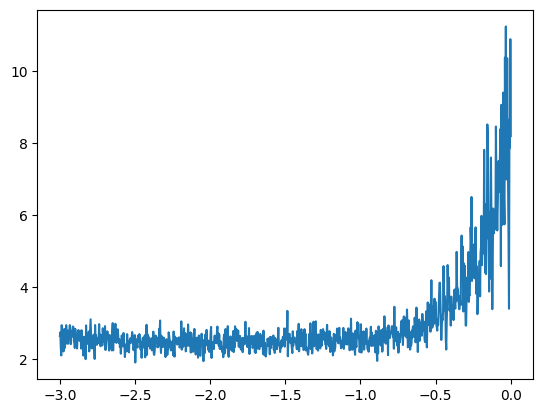

In [65]:
lri, lossi = [], []
for i in range(1000):
    # Get a random batch of data
    ix = torch.randint(0, X.shape[0], (32,))

    # Forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    # print("loss: ", loss.item())

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # Update
    lr = lrs[i]
    for p in params:
        p.data -= lr * p.grad

    # Track learning rate and loss
    lri.append(lre[i])
    lossi.append(loss.item())

plt.plot(lri, lossi)
plt.show()

### Final training with chosen learning rate

We now run a **longer training loop** (10,000 iterations) using the learning rate picked from the sweep above (`0.085`). Each iteration:

- **Samples a random minibatch** of 32 examples from the full dataset.
- **Embeds the characters**, flattens the context, and runs them through the MLP to get logits.
- Computes the **cross-entropy loss** between predicted logits and true next characters.
- Performs **backpropagation** to accumulate gradients.
- Updates each parameter with a simple **SGD step** using the fixed learning rate.

This stage is where most of the learning happens: the model gradually adjusts its weights so that it assigns higher probability to the next characters that actually appear in the training names.

In [66]:
for i in range(10_000):
    # Get a random batch of data
    ix = torch.randint(0, X.shape[0], (32,))

    # Forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # Update
    for p in params:
        # after finding optimal learning rate, we can also decay the learning rate
        p.data -= 0.085 * p.grad 

print("loss: ", loss.item())

loss:  2.2546119689941406


### Train / dev / test split

So far we have been training and evaluating on **the same dataset**, which can lead to **overfitting**: the model might just memorize patterns in the training examples.

To properly measure generalization, we split the full dataset of `(X, Y)` pairs into three disjoint parts:

- **Train set**: used to **fit** the model parameters.
- **Dev (validation) set**: used during development to **tune hyperparameters** (e.g. learning rate, model size).
- **Test set**: only used **once at the end** to report the final performance.

Here we create an 80% / 10% / 10% random split of indices into the rows of `X` and `Y`, then reuse the same forward pass to compute the loss on each split.

In [71]:
# Create train / dev / test splits

def build_dataset(words):
    block_size = 3 # context length, how many characters to look back when predicting the next character
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            
            # crop and append
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [73]:
print("Length of words: ", len(words))
print("n1: ", n1)
print("n2: ", n2)
print("n2 - n1", n2-n1)

Length of words:  32033
n1:  25626
n2:  28829
n2 - n1 3203


In [77]:
lossi, stepi = [], []

for i in range(30_000):
    # Get a random batch of data
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # Update
    for p in params:
        # after finding optimal learning rate, we can also decay the learning rate
        p.data -= 0.001 * p.grad 

print("loss: ", loss.item())

loss:  2.4097959995269775


In [80]:
# Evaluate loss on train / dev / test splits with the *current* parameters

def calculate_loss(Xdev, Ydev):
    emb = C[Xdev] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ydev)
    return loss.item()

print('train loss:', calculate_loss(Xtr, Ytr))
print('dev loss:  ', calculate_loss(Xdev, Ydev))

train loss: 2.3197367191314697
dev loss:   2.3191096782684326


### Model capacity and why we might want a bigger network

In this notebook we deliberately used a **very small model**:

- Character embeddings are only **2-dimensional**.
- The hidden layer has only **100 neurons**.

This makes the model easy to visualize and fast to train, but it also **limits its capacity**:

- A 2D embedding space is a **very tight bottleneck**. All 27 characters must be squeezed into just 2 coordinates, so many characters that behave differently (e.g. vowels vs consonants, or beginning vs ending letters) are forced to share similar representations.
- The hidden layer with 100 units can only represent a relatively small set of nonlinear features of the 3-character context. Complex patterns in the data (like longer-range dependencies, common syllables, or positional effects) may not fit into this space.
- If you plot train/dev/test loss and see that **all of them stay comparatively high**, that is a sign the model is **underfitting** – it is not powerful enough to fully capture the structure in the names, even on the training set.

Increasing the model size (for example, using **higher-dimensional embeddings** like 10, 16, or 32 and a **wider hidden layer** like 200–500 units) gives the network more room to:

- Learn **richer character relationships**: similar letters can cluster together while still leaving room to separate characters that play different roles.
- Represent more complex, nonlinear functions of the context, leading to **lower training loss** and usually better samples.

Of course, larger models also make **overfitting** more likely, which is why the **train/dev/test split** above is important: it lets us scale up capacity while checking whether improvements on the training set also translate into lower dev and test loss.

Number of params:  10281


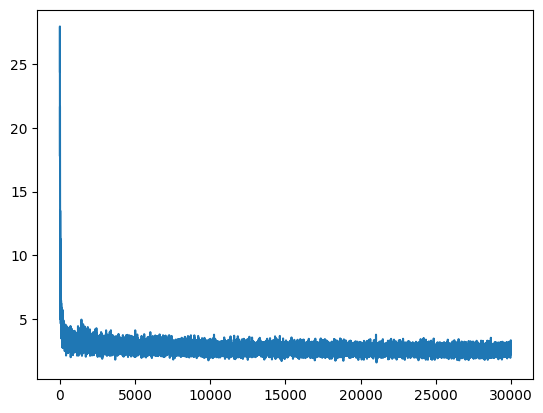

In [84]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator = g)
W1 = torch.randn((6, 300), generator = g)
b1 = torch.randn(300, generator = g)
W2 = torch.randn((300, 27), generator = g)
b2 = torch.randn(27, generator = g)

params = [C, W1, b1, W2, b2]

print("Number of params: ", sum(p.numel() for p in params))

for p in params:
    p.requires_grad = True

lossi, stepi = [], []
for i in range(30_000):
    # Get a random batch of data
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    
    for p in params:
        p.grad = None
    loss.backward()
    
    for p in params:
        p.data -= 0.085 * p.grad

    # store loss and step
    lossi.append(loss.item())
    stepi.append(i)
        
plt.plot(stepi, lossi)
plt.show()

In [85]:
print('train loss:', calculate_loss(Xtr, Ytr))
print('dev loss:  ', calculate_loss(Xdev, Ydev))
print('test loss: ', calculate_loss(Xtest, Ytest))


train loss: 2.5237672328948975
dev loss:   2.5280063152313232
test loss:  2.5236799716949463


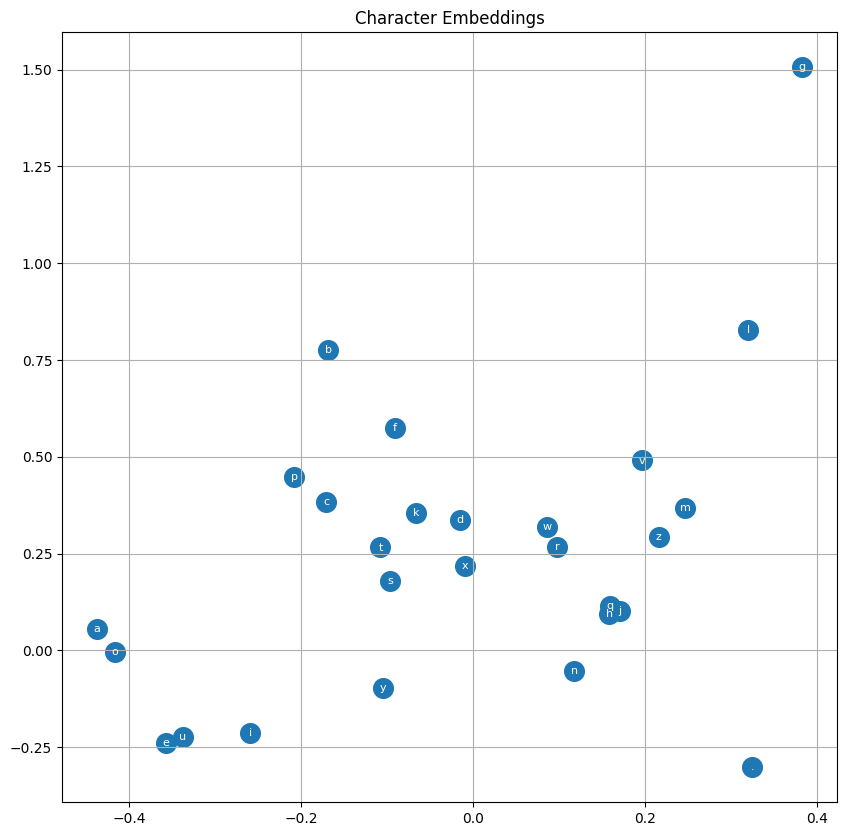

In [88]:
# Visualize the clustering of characters

plt.figure(figsize=(10, 10))
plt.scatter(C[:, 0].data, C[:, 1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', fontsize=8, color='white')

plt.title('Character Embeddings')
plt.grid('minor')
plt.show()

Increasing the neural network size didn't help improve the loss by much. So the bottle-neck might be the vector embedding size, which currently is 2.

### Sampling new names from the trained model

Once the model is trained, we can use it as a **generative model**:

- Start from a context of all start tokens (e.g. `[0, 0, 0]` for `block_size = 3`).
- At each step, run the forward pass to get a **probability distribution over the next character**.
- Sample a next character ID from that distribution, append it to the context, and repeat.
- Stop when we sample the special `'.'` token, and decode the collected character IDs back into a string.

This process turns the learned next-character probabilities into **full baby-name samples**.

In [89]:
# Sampling function to generate new names

def sample_names(num_samples=20, max_len=20, seed=123):
    g = torch.Generator().manual_seed(seed)
    for _ in range(num_samples):
        out = []
        context = [0] * block_size  # start with all '.' tokens

        while True:
            # Forward pass for a single context
            x = torch.tensor([context])  # shape (1, block_size)
            emb = C[x]                  # (1, block_size, 2)
            h = torch.tanh(emb.view(1, -1) @ W1 + b1)  # (1, 100)
            logits = h @ W2 + b2                      # (1, 27)

            # Convert logits to probabilities
            probs = F.softmax(logits, dim=1)          # (1, 27)

            # Sample next character index
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()

            # If we hit the end token, stop
            if ix == 0 or len(out) >= max_len:
                break

            # Append character and update context
            out.append(itos[ix])
            context = context[1:] + [ix]

        print(''.join(out))

# Generate a few example names
sample_names(num_samples=20, max_len=20, seed=2147483647)

celze
loges
raylez
tyh
mellimotta
nollayk
kamor
somiylee
ther
got
kemolie
lavogew
tedo
kamey
mestolyynkaveyny
kolsn
hucemenvon
lah
khyde
dan
